Decision Tree Classifier


Step 1 Read the dataset

In [448]:
from warnings import filterwarnings
filterwarnings('ignore')

In [449]:
import pandas as pd
path = r"C:\Users\admin\Downloads\train.csv"
df = pd.read_csv(path)
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


Step2: Perform basic data quality checks

In [450]:
df.shape

(2000, 21)

In [451]:
df.columns

Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='object')

In [452]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [453]:
# check for missing values
df.isna().sum()

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

In [454]:
df.duplicated().sum()

np.int64(0)

In [455]:
df = df.drop_duplicates()

Step3: Separate data into X and Y features

Y: Drug to be predicted



In [456]:

df.columns

Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='object')

In [457]:
X = df.drop(columns=['price_range'])
Y = df[['price_range']]

In [458]:

X.head()


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,842,0,2.2,0,1,0,7,0.6,188,2,2,20,756,2549,9,7,19,0,0,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,6,905,1988,2631,17,3,7,1,1,0
2,563,1,0.5,1,2,1,41,0.9,145,5,6,1263,1716,2603,11,2,9,1,1,0
3,615,1,2.5,0,0,0,10,0.8,131,6,9,1216,1786,2769,16,8,11,1,0,0
4,1821,1,1.2,0,13,1,44,0.6,141,2,14,1208,1212,1411,8,2,15,1,1,0


Y.head()

Step4 : Data Preprocessing and Data cleaning

In [459]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline



In [460]:
pre = make_pipeline(
    SimpleImputer(strategy='mean'),
    StandardScaler()
).set_output(transform='pandas')


In [461]:
pre

,steps,"[('simpleimputer', ...), ('standardscaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'mean'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [462]:
X_pre = pre.fit_transform(X)
X_pre. head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,-0.902597,-0.990050,0.830779,-1.019184,-0.762495,-1.043966,-1.380644,0.340740,1.349249,-1.101971,-1.305750,-1.408949,-1.146784,0.391703,-0.784983,0.283103,1.462493,-1.786861,-1.006018,0.986097
1,-0.495139,1.010051,-1.253064,0.981177,-0.992890,0.957886,1.155024,0.687548,-0.120059,-0.664768,-0.645989,0.585778,1.704465,0.467317,1.114266,-0.635317,-0.734267,0.559641,0.994018,-1.014099
2,-1.537686,1.010051,-1.253064,0.981177,-0.532099,0.957886,0.493546,1.381165,0.134244,0.209639,-0.645989,1.392684,1.074968,0.441498,-0.310171,-0.864922,-0.368140,0.559641,0.994018,-1.014099
3,-1.419319,1.010051,1.198517,-1.019184,-0.992890,-1.043966,-1.215274,1.034357,-0.261339,0.646842,-0.151168,1.286750,1.236971,0.594569,0.876859,0.512708,-0.002014,0.559641,-1.006018,-1.014099
4,1.325906,1.010051,-0.395011,-1.019184,2.002254,0.957886,0.658915,0.340740,0.021220,-1.101971,0.673534,1.268718,-0.091452,-0.657666,-1.022389,-0.864922,0.730240,0.559641,0.994018,-1.014099



Step5: Split the data into training and testing

In [463]:

from sklearn.model_selection import train_test_split

In [464]:
xtrain,xtest,ytrain,ytest = train_test_split(X_pre,Y,train_size=0.80,random_state=21)


In [465]:

xtrain.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
1490,-0.508796,1.010051,-0.885327,-1.019184,0.159088,-1.043966,-1.105027,-0.006069,-1.080761,-0.664768,0.673534,-0.698961,-1.324987,0.155641,-1.734608,-1.094526,-1.649584,-1.786861,0.994018,-1.014099
965,0.319779,-0.990050,-1.253064,0.981177,-0.762495,-1.043966,-0.719165,-0.699686,-0.176571,1.521249,1.168355,-0.581757,-1.343502,1.648549,-0.310171,-0.864922,1.462493,-1.786861,0.994018,0.986097
1216,-0.183285,-0.990050,-1.007906,0.981177,-0.762495,0.957886,-0.167933,0.687548,-0.487386,-1.101971,1.663176,-0.753055,1.260114,-0.536869,1.114266,0.742313,0.730240,0.559641,-1.006018,0.986097
500,0.089872,1.010051,-1.253064,0.981177,-0.762495,-1.043966,1.210147,-1.393304,-1.024249,1.521249,1.003414,-0.144495,-1.160670,-0.893728,-1.259796,-1.094526,1.645557,-1.786861,-1.006018,0.986097
403,0.540580,1.010051,-0.395011,0.981177,-0.992890,0.957886,1.265271,-1.393304,0.868898,-0.227564,-0.810929,2.244669,0.959252,-0.548856,0.164641,0.512708,-1.466521,0.559641,-1.006018,0.986097


In [466]:

xtest.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
541,-1.014136,-0.990050,-0.395011,0.981177,-0.762495,0.957886,0.328176,0.340740,1.010178,-0.227564,-0.481048,1.309289,1.304086,0.935753,-1.497202,-1.094526,0.181050,0.559641,0.994018,0.986097
1211,-1.196241,1.010051,0.095305,-1.019184,0.619880,0.957886,-1.656260,-0.352878,1.151457,1.521249,-0.151168,1.275480,0.292726,-1.511547,-0.547577,0.053498,-1.283457,0.559641,0.994018,0.986097
1862,-0.445060,-0.990050,1.443675,-1.019184,-0.301703,-1.043966,-0.167933,-1.046495,-1.617624,1.521249,1.168355,0.545207,-0.829721,-0.867909,-1.734608,-0.635317,-0.551204,0.559641,-1.006018,-1.014099
1094,-1.253148,1.010051,-0.027274,-1.019184,-0.992890,-1.043966,-1.656260,1.727974,-1.448088,-0.664768,-1.305750,-0.843213,-0.885265,-1.598226,-1.734608,-0.864922,-0.551204,0.559641,0.994018,0.986097
465,0.784145,1.010051,0.095305,-1.019184,0.159088,0.957886,0.548669,1.034357,-0.628666,-0.664768,0.013773,-0.834197,-0.901466,1.408799,0.402047,0.971917,-0.368140,0.559641,-1.006018,-1.014099


In [467]:


ytrain.head()

,price_range
1490,1
965,3
1216,1
500,0
403,2


In [468]:

ytest.head()

,price_range
541,3
1211,0
1862,0
1094,0
465,3



Step6: Build the Decision Tree mode

In [469]:

from sklearn.tree import DecisionTreeClassifier

In [470]:
dtc = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=3,
    min_samples_leaf=3,
    criterion='gini'
)

In [471]:
dtc.fit(xtrain,ytrain)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,3
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [472]:

dtc.score(xtrain,ytrain)

0.883125

In [473]:

dtc.score(xtest,ytest)

0.8375

Step7: Hyperparameter tuning

In [474]:
from sklearn.model_selection import GridSearchCV

In [475]:
params = {
    'max_depth':[3,4,5,6,7,8,9,10],
    'min_samples_split':[1,2,3,4,5,6,7,8,9],
    'min_samples_leaf':[1,2,3,4,5,6,7,8,9],
    'criterion':['gini','entropy']
}

In [476]:
base_model = DecisionTreeClassifier()

In [477]:
gscv = GridSearchCV(estimator=base_model,param_grid=params,cv=4,scoring='f1_macro')
gscv.fit(xtrain,ytrain)

,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [3, 4, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [1, 2, ...]}"
,scoring,'f1_macro'
,n_jobs,None
,refit,True
,cv,4
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


In [478]:
gscv.best_params_

{'criterion': 'entropy',
 'max_depth': 9,
 'min_samples_leaf': 6,
 'min_samples_split': 4}

In [479]:
gscv.best_score_

np.float64(0.8490817807684409)

In [480]:
gscv.score(xtrain,ytrain)

0.9499689009436852

In [481]:

gscv.score(xtest,ytest)

0.8518071989326463

In [482]:
best_dtc = gscv.best_estimator_
best_dtc


,criterion,'entropy'
,splitter,'best'
,max_depth,9
,min_samples_split,4
,min_samples_leaf,6
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Step8: Evaluation Metrics
Confusion Matrix

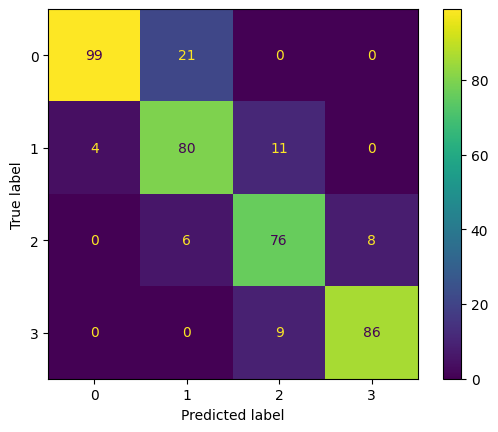

In [483]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(best_dtc,xtest,ytest)

In [484]:
from sklearn.metrics import classification_report
ypred_test = best_dtc.predict(xtest)
ypred_test[:5]


array([3, 0, 0, 0, 3])

In [485]:

ytest.head()

,price_range
541,3
1211,0
1862,0
1094,0
465,3


In [486]:
print(classification_report(ytest,ypred_test))

              precision    recall  f1-score   support

           0       0.96      0.82      0.89       120
           1       0.75      0.84      0.79        95
           2       0.79      0.84      0.82        90
           3       0.91      0.91      0.91        95

    accuracy                           0.85       400
   macro avg       0.85      0.85      0.85       400
weighted avg       0.86      0.85      0.85       400



Step9: Plot the decision tree

In [487]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

In [488]:

xtrain.columns

Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi'],
      dtype='object')

In [489]:
fea_names = xtrain.columns
fea_names

Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi'],
      dtype='object')

In [490]:
Y['price_range'].unique()

array([1, 2, 3, 0])

In [491]:
best_dtc.classes_

array([0, 1, 2, 3])

In [492]:
class_names=[str(c) for c in best_dtc.classes_]

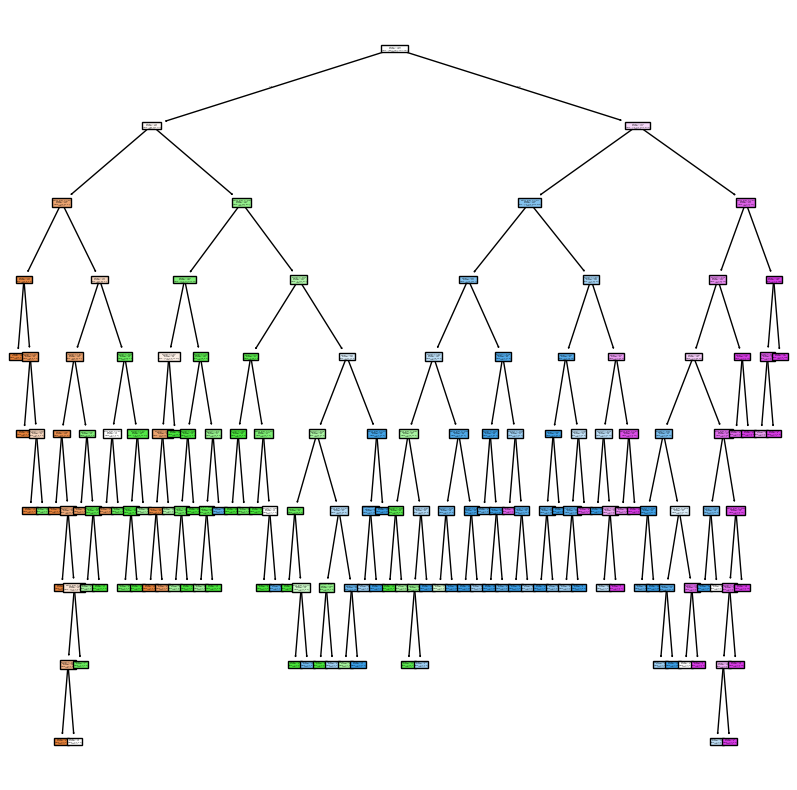

In [493]:
plt.figure(figsize=(10,10))
plot_tree(best_dtc,feature_names=[str(feat) for feat in fea_names] ,class_names=class_names,filled=True )
plt.show()

In [494]:
best_dtc.feature_importances_

array([0.13025439, 0.        , 0.00085829, 0.        , 0.00107607,
       0.00221946, 0.        , 0.        , 0.00317569, 0.        ,
       0.00171678, 0.0529453 , 0.10679375, 0.69367675, 0.00130662,
       0.        , 0.00504047, 0.        , 0.00093643, 0.        ])

In [495]:
imp_features_bymodel = pd.Series(best_dtc.feature_importances_,index=fea_names)
imp_features_bymodel.sort_values(ascending=False)

ram              0.693677
battery_power    0.130254
px_width         0.106794
px_height        0.052945
talk_time        0.005040
mobile_wt        0.003176
four_g           0.002219
pc               0.001717
sc_h             0.001307
fc               0.001076
touch_screen     0.000936
clock_speed      0.000858
dual_sim         0.000000
blue             0.000000
int_memory       0.000000
m_dep            0.000000
n_cores          0.000000
sc_w             0.000000
three_g          0.000000
wifi             0.000000
dtype: float64

<Axes: >

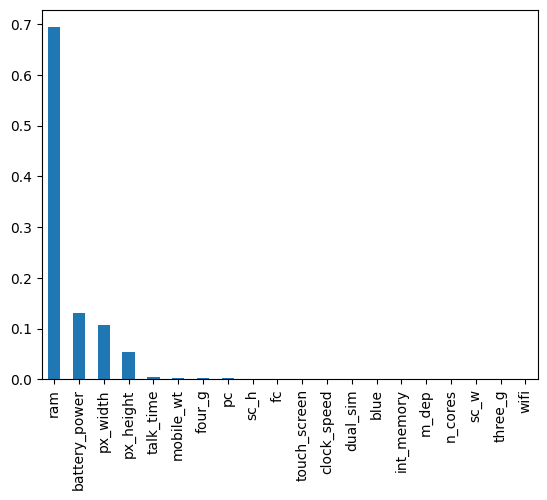

In [496]:
imp_features_bymodel.sort_values(ascending=False).plot(kind='bar')

Above model is providing scores above 0.80, we can cpnsider this model for final model building and use it for out of sample predictions
Step 10: Out of Sample Predictions

In [497]:
path2 = r"C:\Users\admin\Downloads\test.csv"
xnew = pd.read_csv(path2)
xnew.head()


,id,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,...,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,1,1043,1,1.8,1,14,0,5,0.1,193,...,16,226,1412,3476,12,7,2,0,1,0
1,2,841,1,0.5,1,4,1,61,0.8,191,...,12,746,857,3895,6,0,7,1,0,0
2,3,1807,1,2.8,0,1,0,27,0.9,186,...,4,1270,1366,2396,17,10,10,0,1,1
3,4,1546,0,0.5,1,18,1,25,0.5,96,...,20,295,1752,3893,10,0,7,1,1,0
4,5,1434,0,1.4,0,11,1,49,0.5,108,...,18,749,810,1773,15,8,7,1,0,1


In [498]:
pre

,steps,"[('simpleimputer', ...), ('standardscaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'mean'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [501]:
xnew.dtypes

id                 int64
battery_power      int64
blue               int64
clock_speed      float64
dual_sim           int64
fc                 int64
four_g             int64
int_memory         int64
m_dep            float64
mobile_wt          int64
n_cores            int64
pc                 int64
px_height          int64
px_width           int64
ram                int64
sc_h               int64
sc_w               int64
talk_time          int64
three_g            int64
touch_screen       int64
wifi               int64
dtype: object

In [499]:
xnew_pre = pre.transform(xnew)
xnew_pre.head()

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- id


In [ ]:
drug_predicted = best_dtc.predict(xnew_pre)

In [ ]:
drug_predicted[:10]

array(['DrugY', 'DrugY', 'drugX', 'drugB', 'DrugY', 'DrugY', 'DrugY',
       'drugB', 'DrugY', 'drugX'], dtype=object)

In [ ]:
xnew['Drug_Predicted'] = drug_predicted

In [ ]:
xnew.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug_Predicted
0,22.0,F,HIGH,NORMAL,22.818,DrugY
1,15.0,M,HIGH,NORMAL,17.206,DrugY
2,67.0,M,NORMAL,NORMAL,9.514,drugX
3,68.0,M,NaN,HIGH,11.009,drugB
4,70.0,F,NORMAL,HIGH,NaN,DrugY


Step11: Save the results to csv file

In [ ]:
xnew.to_csv('Drug Results.csv',index=False)